## Importing Libraries & Data Load

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
# Evaluation Metrics
from sklearn.metrics import accuracy_score

In [27]:
# Define the sheet name to read data from
sheet_name = 'vw_ChurnData'

# Read the data from the specified sheet into a pandas DataFrame
data = pd.read_excel('../ViewsData_for_Prediction/prediction_data.xlsx', sheet_name=sheet_name)

# Display the first few rows of the fetched data
data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,11596-KAR,Female,40,No,Karnataka,15,11,Deal 4,Yes,No,...,Bank Withdrawal,49.200001,571.150024,0.0,80,114.959999,766.109985,Stayed,Others,Others
1,11604-HAR,Female,38,Yes,Haryana,4,8,NaN,Yes,Yes,...,Bank Withdrawal,104.400002,6721.600098,0.0,0,892.799988,7614.399902,Stayed,Others,Others
2,11616-TAM,Male,26,No,Tamil Nadu,6,2,NaN,Yes,Yes,...,Bank Withdrawal,68.699997,1416.199951,0.0,0,650.000000,2066.199951,Stayed,Others,Others
3,11647-GUJ,Male,44,No,Gujarat,2,4,Deal 4,Yes,Yes,...,Bank Withdrawal,69.099998,1083.699951,0.0,0,223.839996,1307.540039,Stayed,Others,Others
4,11647-TAM,Male,81,No,Tamil Nadu,1,21,NaN,Yes,Yes,...,Bank Withdrawal,93.750000,5625.549805,0.0,0,125.970001,5751.520020,Stayed,Others,Others


## Data Preprocessing

In [28]:
# Drop columns that won't be used for prediction
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)
data.head()

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
0,Female,40,No,Karnataka,15,11,Deal 4,Yes,No,Yes,...,Month-to-Month,Yes,Bank Withdrawal,49.200001,571.150024,0.0,80,114.959999,766.109985,Stayed
1,Female,38,Yes,Haryana,4,8,NaN,Yes,Yes,Yes,...,One Year,Yes,Bank Withdrawal,104.400002,6721.600098,0.0,0,892.799988,7614.399902,Stayed
2,Male,26,No,Tamil Nadu,6,2,NaN,Yes,Yes,Yes,...,One Year,Yes,Bank Withdrawal,68.699997,1416.199951,0.0,0,650.000000,2066.199951,Stayed
3,Male,44,No,Gujarat,2,4,Deal 4,Yes,Yes,Yes,...,Month-to-Month,Yes,Bank Withdrawal,69.099998,1083.699951,0.0,0,223.839996,1307.540039,Stayed
4,Male,81,No,Tamil Nadu,1,21,NaN,Yes,Yes,Yes,...,Two Year,No,Bank Withdrawal,93.750000,5625.549805,0.0,0,125.970001,5751.520020,Stayed


In [29]:
data.columns

Index(['Gender', 'Age', 'Married', 'State', 'Number_of_Referrals',
       'Tenure_in_Months', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
       'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
       'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV',
       'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data', 'Contract',
       'Paperless_Billing', 'Payment_Method', 'Monthly_Charge',
       'Total_Charges', 'Total_Refunds', 'Total_Extra_Data_Charges',
       'Total_Long_Distance_Charges', 'Total_Revenue', 'Customer_Status'],
      dtype='object')

In [30]:
# List of columns to be label encoded
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'

]

# Encode categorical variables except the target variable
label_encoders = {}
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])
    
data.head()

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
0,0,40,0,9,15,11,3,1,0,1,...,0,1,0,49.200001,571.150024,0.0,80,114.959999,766.109985,Stayed
1,0,38,1,6,4,8,5,1,1,1,...,1,1,0,104.400002,6721.600098,0.0,0,892.799988,7614.399902,Stayed
2,1,26,0,17,6,2,5,1,1,1,...,1,1,0,68.699997,1416.199951,0.0,0,650.000000,2066.199951,Stayed
3,1,44,0,5,2,4,3,1,1,1,...,0,1,0,69.099998,1083.699951,0.0,0,223.839996,1307.540039,Stayed
4,1,81,0,17,1,21,5,1,1,1,...,2,0,0,93.750000,5625.549805,0.0,0,125.970001,5751.520020,Stayed


In [31]:
# Manually encode the target variable 'Customer_Status'
data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# Split data into features and target
X = data.drop('Customer_Status', axis=1)
X.head()

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,...,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
0,0,40,0,9,15,11,3,1,0,1,...,0,0,1,0,49.200001,571.150024,0.0,80,114.959999,766.109985
1,0,38,1,6,4,8,5,1,1,1,...,1,1,1,0,104.400002,6721.600098,0.0,0,892.799988,7614.399902
2,1,26,0,17,6,2,5,1,1,1,...,1,1,1,0,68.699997,1416.199951,0.0,0,650.000000,2066.199951
3,1,44,0,5,2,4,3,1,1,1,...,1,0,1,0,69.099998,1083.699951,0.0,0,223.839996,1307.540039
4,1,81,0,17,1,21,5,1,1,1,...,1,2,0,0,93.750000,5625.549805,0.0,0,125.970001,5751.520020


In [32]:

y = data['Customer_Status']
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Customer_Status, dtype: int64

In [33]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test)

(4805, 1202)

##  Train and Evaluation

### Random Forest

In [34]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Evaluate Model
# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Confusion Matrix:
[[807  41]
 [119 235]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       848
           1       0.85      0.66      0.75       354

    accuracy                           0.87      1202
   macro avg       0.86      0.81      0.83      1202
weighted avg       0.87      0.87      0.86      1202



### Logistic Regression

In [35]:
# Initialize the Random Forest Classifier
log_model = LogisticRegression()

# Train the model
log_model.fit(X_train, y_train)

# Evaluate Model
# Make predictions
log_pred = log_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))
print("\nClassification Report:")
print(classification_report(y_test, log_pred))

Confusion Matrix:
[[760  88]
 [168 186]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       848
           1       0.68      0.53      0.59       354

    accuracy                           0.79      1202
   macro avg       0.75      0.71      0.72      1202
weighted avg       0.78      0.79      0.78      1202



C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Decision Tree

In [36]:
# Initialize the Random Forest Classifier
dt_model = DecisionTreeClassifier()

# Train the model
dt_model.fit(X_train, y_train)

# Evaluate Model
# Make predictions
dt_pred = dt_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Confusion Matrix:
[[728 120]
 [112 242]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       848
           1       0.67      0.68      0.68       354

    accuracy                           0.81      1202
   macro avg       0.77      0.77      0.77      1202
weighted avg       0.81      0.81      0.81      1202



### Gradient Boost

In [37]:
# Initialize the Random Forest Classifier
gb_model = GradientBoostingClassifier()

# Train the model
gb_model.fit(X_train, y_train)

# Evaluate Model
# Make predictions
gb_pred = gb_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, gb_pred))
print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

Confusion Matrix:
[[800  48]
 [112 242]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       848
           1       0.83      0.68      0.75       354

    accuracy                           0.87      1202
   macro avg       0.86      0.81      0.83      1202
weighted avg       0.86      0.87      0.86      1202



### SVM

In [38]:
# Initialize the Random Forest Classifier
svm_model = SVC()

# Train the model
svm_model.fit(X_train, y_train)

# Evaluate Model
# Make predictions
svm_pred = svm_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

Confusion Matrix:
[[775  73]
 [193 161]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       848
           1       0.69      0.45      0.55       354

    accuracy                           0.78      1202
   macro avg       0.74      0.68      0.70      1202
weighted avg       0.77      0.78      0.76      1202



### Kneighbor Classifier

In [39]:
# Initialize the Random Forest Classifier
knn_model = KNeighborsClassifier()

# Train the model
knn_model.fit(X_train, y_train)

# Evaluate Model
# Make predictions
knn_pred = knn_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))
print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

Confusion Matrix:
[[778  70]
 [188 166]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       848
           1       0.70      0.47      0.56       354

    accuracy                           0.79      1202
   macro avg       0.75      0.69      0.71      1202
weighted avg       0.78      0.79      0.77      1202



### Model Selection

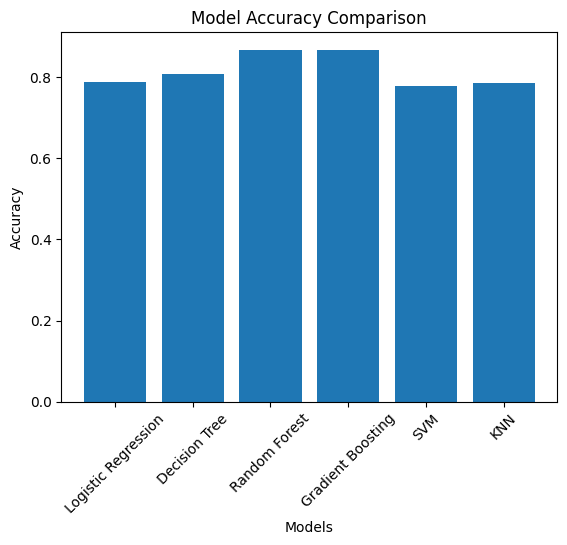

In [40]:
model_accuracies = {
    "Logistic Regression": accuracy_score(y_test, log_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Gradient Boosting": accuracy_score(y_test, gb_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "KNN": accuracy_score(y_test, knn_pred),
}

# Extract names and values
models = list(model_accuracies.keys())
accuracies = list(model_accuracies.values())

# Create bar chart
plt.figure()
plt.bar(models, accuracies)

# Labels
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

# Rotate x labels for readability
plt.xticks(rotation=45)

plt.show()

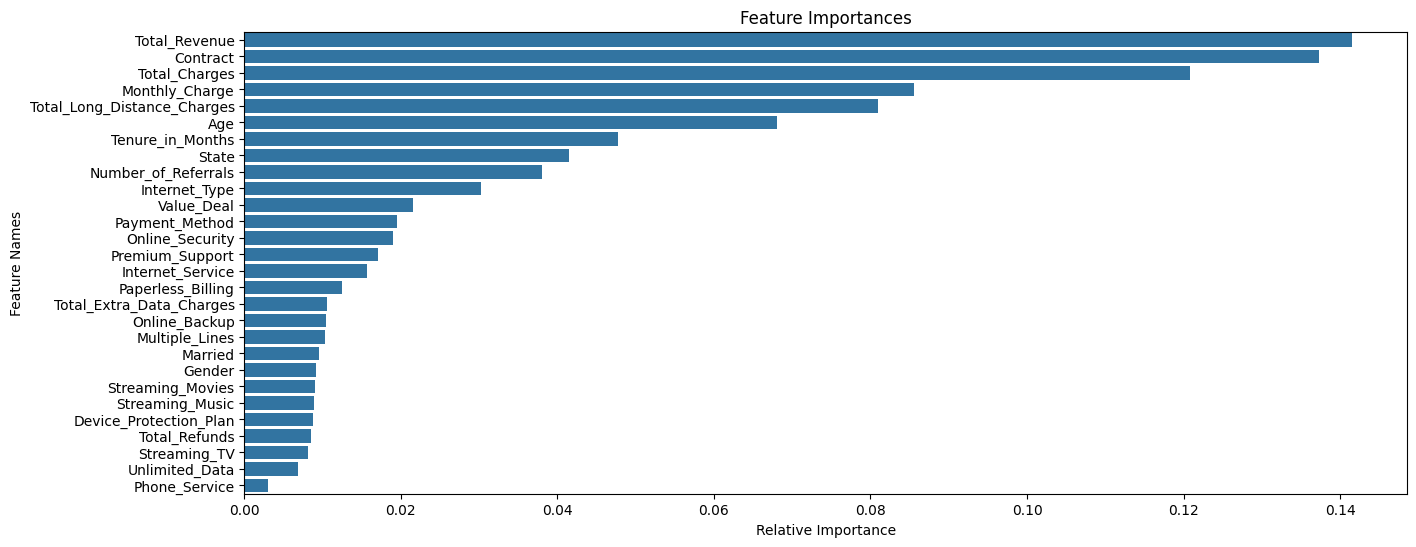

In [41]:


# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()

##  Use Model for Prediction on New Data

In [43]:

# Define the sheet name to read data from
sheet_name = 'vw_JoinData'

# Read the data from the specified sheet into a pandas DataFrame
new_data = pd.read_excel("../ViewsData_for_Prediction/prediction_data.xlsx", sheet_name=sheet_name)

# Display the first few rows of the fetched data
new_data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,11751-TAM,Female,18,No,Tamil Nadu,5,7,Deal 5,No,No,...,Mailed Check,24.299999,38.450001,0.0,0,0.000000,38.450001,Joined,Others,Others
1,13058-MAD,Female,58,No,Madhya Pradesh,13,22,NaN,Yes,No,...,Mailed Check,46.099998,130.149994,0.0,0,7.980000,138.130005,Joined,Others,Others
2,13123-BIH,Female,46,No,Bihar,13,18,Deal 5,Yes,No,...,Bank Withdrawal,100.199997,198.500000,0.0,10,45.119999,253.619995,Joined,Others,Others
3,17597-HAR,Female,33,Yes,Haryana,2,6,Deal 5,No,No,...,Bank Withdrawal,29.850000,29.850000,0.0,0,0.000000,29.850000,Joined,Others,Others
4,24696-BIH,Female,69,Yes,Bihar,0,20,Deal 5,Yes,No,...,Bank Withdrawal,43.950001,85.099998,0.0,0,38.180000,123.279999,Joined,Others,Others


In [44]:


# Retain the original DataFrame to preserve unencoded columns
original_data = new_data.copy()

# Retain the Customer_ID column
customer_ids = new_data['Customer_ID']

# Drop columns that won't be used for prediction in the encoded DataFrame
new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)

new_data.columns

Index(['Gender', 'Age', 'Married', 'State', 'Number_of_Referrals',
       'Tenure_in_Months', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
       'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
       'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV',
       'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data', 'Contract',
       'Paperless_Billing', 'Payment_Method', 'Monthly_Charge',
       'Total_Charges', 'Total_Refunds', 'Total_Extra_Data_Charges',
       'Total_Long_Distance_Charges', 'Total_Revenue'],
      dtype='object')

In [45]:
# Encode categorical variables using the saved label encoders
for column in new_data.select_dtypes(include=['object']).columns:

    new_data[column] = label_encoders[column].transform(new_data[column])

# Make predictions
new_predictions = rf_model.predict(new_data)

# Add predictions to the original DataFrame
original_data['Customer_Status_Predicted'] = new_predictions
original_data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason,Customer_Status_Predicted
0,11751-TAM,Female,18,No,Tamil Nadu,5,7,Deal 5,No,No,...,24.299999,38.450001,0.0,0,0.000000,38.450001,Joined,Others,Others,1
1,13058-MAD,Female,58,No,Madhya Pradesh,13,22,NaN,Yes,No,...,46.099998,130.149994,0.0,0,7.980000,138.130005,Joined,Others,Others,1
2,13123-BIH,Female,46,No,Bihar,13,18,Deal 5,Yes,No,...,100.199997,198.500000,0.0,10,45.119999,253.619995,Joined,Others,Others,1
3,17597-HAR,Female,33,Yes,Haryana,2,6,Deal 5,No,No,...,29.850000,29.850000,0.0,0,0.000000,29.850000,Joined,Others,Others,1
4,24696-BIH,Female,69,Yes,Bihar,0,20,Deal 5,Yes,No,...,43.950001,85.099998,0.0,0,38.180000,123.279999,Joined,Others,Others,1


In [46]:
# Filter the DataFrame to include only records predicted as "Churned"
original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

original_data['Customer_Status_Predicted'].unique()

array([1], dtype=int64)

In [47]:
# Save the results
original_data.to_csv("../ViewsData_for_Prediction/Predictions.csv", index=False)